# Multi-Tissue HCE — Lung + Brain

| | v3 (lung only) | **This notebook** |
|---|---|---|
| Tissues | Lung | **Lung + Brain** |
| Gene representation | Ensembl IDs | **Gene symbols (feature_name)** |
| Tissue conditioning | None | **Tissue prefix in gene text** |
| Label scheme | Single-label (finest level) | **Single-label (finest level)** |
| HCE | Corrected | **Corrected** |
| Validation | Lung test set | **Lung + Brain test sets + All_cells zero-shot** |

**Why gene symbols?** Both HCA datasets expose a `feature_name` column with HGNC symbols.
All_cells uses gene symbols directly — switching to symbols raises the gene overlap with
All_cells from 0 → ~71%, making the zero-shot validation meaningful.

## 1. Imports

In [1]:
import os, sys, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import scanpy as sc
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import h5py

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
from cell2sentence.hce_trainer import build_reachability_matrix_from_ontology

warnings.filterwarnings('ignore')
print('=' * 60)
print('  IMPORTS OK')
print(f'  PyTorch : {torch.__version__}')
print(f'  CUDA    : {torch.cuda.is_available()} | devices: {torch.cuda.device_count()}')
print('=' * 60)

/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/c2s-justin/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  IMPORTS OK
  PyTorch : 2.10.0+cu128
  CUDA    : True | devices: 1


## 2. Configuration

In [2]:
# --- Paths ---
LUNG_H5AD_PATH   = 'lung.h5ad'
BRAIN_H5AD_PATH  = 'brain_new.h5ad'
ALL_CELLS_PATH   = 'All_cells.h5ad'
OUT_DIR          = 'multi_tissue_results'
BEST_MODEL_PATH  = os.path.join(OUT_DIR, 'best_model.pt')
C2S_MODEL_NAME   = 'vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation'

# --- Lung annotation columns (same as v3) ---
LUNG_ANN_COL   = 'ann_finest_level'
LUNG_LEVEL_COLS = ['ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5']

# --- Brain annotation columns ---
BRAIN_ANN_COL    = 'cell_type'          # finest level (13 types)
BRAIN_COARSE_COL = 'supercluster_term'  # coarser level (10 types)

# --- All_cells annotation column ---
ALL_CELLS_ANN_COL = 'predicted.high_hierarchy'

# --- Hyperparameters ---
TOP_K_GENES        = 100
MAX_CELLS_PER_TYPE = 1000
MIN_CELLS_PER_TYPE = 100
TEST_FRAC          = 0.15
VAL_FRAC           = 0.10
BATCH_SIZE         = 8
N_EPOCHS           = 10
LEARNING_RATE      = 1e-4
WEIGHT_DECAY       = 1e-2
WARMUP_STEPS       = 200   # increased for larger combined dataset
MAX_SEQ_LEN        = 512
MAX_WEIGHT         = 10.0
SEED               = 42

os.makedirs(OUT_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'  Device          : {device}')
print(f'  Output dir      : {OUT_DIR}')
print(f'  Epochs          : {N_EPOCHS}')
print(f'  LR              : {LEARNING_RATE}')
print(f'  Max cells/type  : {MAX_CELLS_PER_TYPE}')
print(f'  Min cells/type  : {MIN_CELLS_PER_TYPE}')
print('[OK] Config ready')

  Device          : cuda
  Output dir      : multi_tissue_results
  Epochs          : 10
  LR              : 0.0001
  Max cells/type  : 1000
  Min cells/type  : 100
[OK] Config ready


## 3. Load & Balance Lung Dataset

In [3]:
print('=' * 60)
print('  STEP 1/9 - Load lung dataset')
print('=' * 60)
t0 = time.time()

adata_lung = sc.read_h5ad(LUNG_H5AD_PATH, backed='r')
print(f'  Raw shape : {adata_lung.shape}')

# Gene symbols for lung (feature_name instead of Ensembl IDs)
lung_gene_symbols = np.array(adata_lung.var['feature_name'].astype(str))

def is_valid(value):
    if pd.isna(value): return False
    return str(value).strip().lower() not in ('', 'nan', 'none', 'unknown', 'na', 'n/a')

valid_mask = adata_lung.obs[LUNG_ANN_COL].apply(is_valid)
lung_obs   = adata_lung.obs[valid_mask].copy()
lung_valid_indices = np.where(valid_mask.values)[0]

# Cap at MAX_CELLS_PER_TYPE
labels = lung_obs[LUNG_ANN_COL].astype(str).values
sampled = []
for lbl in np.unique(labels):
    pos = np.where(labels == lbl)[0]
    if len(pos) > MAX_CELLS_PER_TYPE:
        pos = np.random.choice(pos, MAX_CELLS_PER_TYPE, replace=False)
    sampled.extend(pos.tolist())
sampled = np.sort(np.array(sampled, dtype=np.int64))
lung_obs = lung_obs.iloc[sampled].copy()
lung_valid_indices = lung_valid_indices[sampled]

# Apply MIN_CELLS_PER_TYPE filter
counts = lung_obs[LUNG_ANN_COL].astype(str).value_counts()
keep   = counts[counts >= MIN_CELLS_PER_TYPE].index
dropped = counts[counts < MIN_CELLS_PER_TYPE]
if len(dropped):
    print(f'  Dropping {len(dropped)} lung class(es) with < {MIN_CELLS_PER_TYPE} cells:')
    for ct, n in dropped.items(): print(f'    - {ct}: {n}')
mask = lung_obs[LUNG_ANN_COL].isin(keep)
lung_obs = lung_obs[mask].copy()
lung_valid_indices = lung_valid_indices[mask.values]

print(f'  Cells kept     : {len(lung_obs):,}')
print(f'  Cell types     : {lung_obs[LUNG_ANN_COL].nunique()}')
print(f'  Elapsed        : {time.time()-t0:.1f}s')
print('[OK] Lung dataset loaded')

  STEP 1/9 - Load lung dataset
  Raw shape : (2282447, 55329)
  Dropping 2 lung class(es) with < 100 cells:
    - Hematopoietic stem cells: 61
    - Lymphatic EC proliferating: 28
  Cells kept     : 57,522
  Cell types     : 59
  Elapsed        : 27.6s
[OK] Lung dataset loaded


## 4. Load & Balance Brain Dataset

In [4]:
print('=' * 60)
print('  STEP 2/9 - Load brain dataset')
print('=' * 60)
t0 = time.time()

adata_brain = sc.read_h5ad(BRAIN_H5AD_PATH, backed='r')
print(f'  Raw shape : {adata_brain.shape}')

# Gene symbols for brain
brain_gene_symbols = np.array(adata_brain.var['feature_name'].astype(str))

valid_mask_b  = adata_brain.obs[BRAIN_ANN_COL].apply(is_valid)
brain_obs     = adata_brain.obs[valid_mask_b].copy()
brain_valid_indices = np.where(valid_mask_b.values)[0]

# Cap at MAX_CELLS_PER_TYPE
labels_b = brain_obs[BRAIN_ANN_COL].astype(str).values
sampled_b = []
for lbl in np.unique(labels_b):
    pos = np.where(labels_b == lbl)[0]
    if len(pos) > MAX_CELLS_PER_TYPE:
        pos = np.random.choice(pos, MAX_CELLS_PER_TYPE, replace=False)
    sampled_b.extend(pos.tolist())
sampled_b = np.sort(np.array(sampled_b, dtype=np.int64))
brain_obs = brain_obs.iloc[sampled_b].copy()
brain_valid_indices = brain_valid_indices[sampled_b]

# Apply MIN_CELLS_PER_TYPE filter
counts_b = brain_obs[BRAIN_ANN_COL].astype(str).value_counts()
keep_b   = counts_b[counts_b >= MIN_CELLS_PER_TYPE].index
dropped_b = counts_b[counts_b < MIN_CELLS_PER_TYPE]
if len(dropped_b):
    print(f'  Dropping {len(dropped_b)} brain class(es) with < {MIN_CELLS_PER_TYPE} cells:')
    for ct, n in dropped_b.items(): print(f'    - {ct}: {n}')
mask_b = brain_obs[BRAIN_ANN_COL].isin(keep_b)
brain_obs = brain_obs[mask_b].copy()
brain_valid_indices = brain_valid_indices[mask_b.values]

print(f'  Cells kept     : {len(brain_obs):,}')
print(f'  Cell types     : {brain_obs[BRAIN_ANN_COL].nunique()}')
print(f'  Types          : {sorted(brain_obs[BRAIN_ANN_COL].unique())}')
print(f'  Elapsed        : {time.time()-t0:.1f}s')
print('[OK] Brain dataset loaded')

  STEP 2/9 - Load brain dataset
  Raw shape : (888263, 58232)
  Cells kept     : 13,000
  Cell types     : 13
  Types          : ['Bergmann glial cell', 'astrocyte', 'central nervous system macrophage', 'choroid plexus epithelial cell', 'committed oligodendrocyte precursor', 'endothelial cell', 'ependymal cell', 'fibroblast', 'microglial cell', 'oligodendrocyte', 'oligodendrocyte precursor cell', 'pericyte', 'vascular associated smooth muscle cell']
  Elapsed        : 2.9s
[OK] Brain dataset loaded


## 5. Build Combined Hierarchy

In [5]:
print('=' * 60)
print('  STEP 3/9 - Build combined cell-type hierarchy')
print('=' * 60)

# --- Lung ontology (same logic as v3) ---
lung_ontology = {}
level_cols = [c for c in LUNG_LEVEL_COLS if c in lung_obs.columns]
cols_ordered = level_cols + [LUNG_ANN_COL]
for k in range(1, len(cols_ordered)):
    parent_col, child_col = cols_ordered[k-1], cols_ordered[k]
    pairs = lung_obs[[parent_col, child_col]].dropna().drop_duplicates()
    for _, row in pairs.iterrows():
        p, ch = str(row[parent_col]), str(row[child_col])
        if is_valid(p) and is_valid(ch) and ch not in lung_ontology:
            lung_ontology[ch] = p
# Lung root nodes
if cols_ordered[0] in lung_obs.columns:
    for val in lung_obs[cols_ordered[0]].dropna().unique():
        if is_valid(val) and str(val) not in lung_ontology:
            lung_ontology[str(val)] = None

# --- Brain ontology: cell_type → supercluster_term ---
brain_ontology = {}
pairs_b = brain_obs[[BRAIN_COARSE_COL, BRAIN_ANN_COL]].dropna().drop_duplicates()
for _, row in pairs_b.iterrows():
    child  = str(row[BRAIN_ANN_COL])
    parent = str(row[BRAIN_COARSE_COL])
    brain_ontology[child] = parent
# Brain supercluster roots
for val in brain_obs[BRAIN_COARSE_COL].dropna().unique():
    if str(val) not in brain_ontology:
        brain_ontology[str(val)] = None

# --- Merge ---
combined_ontology = {**lung_ontology, **brain_ontology}

print(f'  Lung ontology entries  : {len(lung_ontology)}')
print(f'  Brain ontology entries : {len(brain_ontology)}')
print(f'  Combined entries       : {len(combined_ontology)}')
pd.DataFrame(list(combined_ontology.items()), columns=['child','parent']).to_csv(
    os.path.join(OUT_DIR, 'ontology.csv'), index=False)
print('[OK] Combined hierarchy built')

  STEP 3/9 - Build combined cell-type hierarchy
  Lung ontology entries  : 91
  Brain ontology entries : 23
  Combined entries       : 114
[OK] Combined hierarchy built


## 6. Cell-to-Text Conversion

In [6]:
print('=' * 60)
print('  STEP 4/9 - Cell-to-text conversion (gene symbols + tissue prefix)')
print('=' * 60)
t0 = time.time()

def cell_to_text_backed(h5_X, row_idx, gene_symbols, top_k=100, tissue_prefix=''):
    """Stream one row from a backed CSR X matrix and return top-k gene symbol text."""
    indptr = h5_X['indptr']
    start, end = int(indptr[row_idx]), int(indptr[row_idx + 1])
    if start == end:
        return ''
    vals = h5_X['data'][start:end]
    cols = h5_X['indices'][start:end]
    if len(vals) == 0:
        return ''
    if len(vals) <= top_k:
        order = np.argsort(vals)[::-1]
    else:
        order = np.argpartition(vals, -top_k)[-top_k:]
        order = order[np.argsort(vals[order])[::-1]]
    genes = ' '.join(str(gene_symbols[cols[j]]) for j in order if vals[j] > 0)
    return f'{tissue_prefix}{genes}' if tissue_prefix else genes

# --- Lung ---
print(f'  Converting {len(lung_valid_indices):,} lung cells ...')
with h5py.File(LUNG_H5AD_PATH, 'r') as _h5:
    h5_X_lung = _h5['X']
    lung_texts = [
        cell_to_text_backed(h5_X_lung, int(lung_valid_indices[i]),
                            lung_gene_symbols, TOP_K_GENES, tissue_prefix='lung ')
        for i in tqdm(range(len(lung_valid_indices)), desc='  lung', leave=False)
    ]

# --- Brain ---
print(f'  Converting {len(brain_valid_indices):,} brain cells ...')
with h5py.File(BRAIN_H5AD_PATH, 'r') as _h5:
    h5_X_brain = _h5['X']
    brain_texts = [
        cell_to_text_backed(h5_X_brain, int(brain_valid_indices[i]),
                            brain_gene_symbols, TOP_K_GENES, tissue_prefix='brain ')
        for i in tqdm(range(len(brain_valid_indices)), desc='  brain', leave=False)
    ]

# Filter empty
lung_keep  = [i for i, t in enumerate(lung_texts)  if t.strip()]
brain_keep = [i for i, t in enumerate(brain_texts) if t.strip()]
lung_texts  = [lung_texts[i]  for i in lung_keep]
brain_texts = [brain_texts[i] for i in brain_keep]
lung_labels  = lung_obs[LUNG_ANN_COL].iloc[lung_keep].astype(str).values
brain_labels = brain_obs[BRAIN_ANN_COL].iloc[brain_keep].astype(str).values
lung_tissue_ids  = np.zeros(len(lung_texts),  dtype=int)  # 0 = lung
brain_tissue_ids = np.ones(len(brain_texts),  dtype=int)  # 1 = brain

# Combine
all_texts      = lung_texts  + brain_texts
all_labels_str = np.concatenate([lung_labels, brain_labels])
all_tissue_ids = np.concatenate([lung_tissue_ids, brain_tissue_ids])

print(f'  Lung cells       : {len(lung_texts):,}')
print(f'  Brain cells      : {len(brain_texts):,}')
print(f'  Total cells      : {len(all_texts):,}')
print(f'  Sample lung  text: {lung_texts[0][:80]} ...')
print(f'  Sample brain text: {brain_texts[0][:80]} ...')
print(f'  Elapsed          : {time.time()-t0:.1f}s')
print('[OK] Cell texts ready')

  STEP 4/9 - Cell-to-text conversion (gene symbols + tissue prefix)
  Converting 57,522 lung cells ...


  Converting 13,000 brain cells ...


  Lung cells       : 57,522
  Brain cells      : 13,000
  Total cells      : 70,522
  Sample lung  text: lung KRT14 S100A2 MT-CO1 KRT6A RPS2 PTMA MALAT1 KRT17 RPLP1 RPL41 MT-CO3 GAPDH S ...
  Sample brain text: brain MALAT1 PCDH9 QKI CTNNA3 ST18 DLG2 NKAIN2 IL1RAPL1 FMNL2 MAGI2 PLP1 ELMO1 N ...
  Elapsed          : 79.4s
[OK] Cell texts ready


## 7. Class Vocabulary, Dataset, and Splits

In [7]:
print('=' * 60)
print('  STEP 5/9 - Tokenizer, class vocab, Dataset, splits')
print('=' * 60)
t0 = time.time()

print('  Loading tokenizer ...')
tokenizer = AutoTokenizer.from_pretrained(C2S_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Build combined class vocabulary
leaf_classes_set = set(all_labels_str)
all_nodes = set()
for child, parent in combined_ontology.items():
    all_nodes.add(child)
    if parent: all_nodes.add(parent)
all_nodes |= leaf_classes_set

class_names   = sorted(all_nodes)
class_to_idx  = {name: idx for idx, name in enumerate(class_names)}
n_classes     = len(class_names)
leaf_classes  = sorted(leaf_classes_set)
leaf_indices  = [class_to_idx[c] for c in leaf_classes]
leaf_index_set = set(leaf_indices)

labels_encoded = np.array([class_to_idx[all_labels_str[i]] for i in range(len(all_labels_str))], dtype=int)

print(f'  Total classes (leaf + ancestors) : {n_classes}')
print(f'  Leaf classes                     : {len(leaf_classes)}')
print(f'    Lung leaf classes  : {len(set(lung_labels))}')
print(f'    Brain leaf classes : {len(set(brain_labels))}')

class CellTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_length = tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_length,
            padding='max_length', return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'label':          torch.tensor(self.labels[idx], dtype=torch.long)}

# Stratified split (stratify by combined label + tissue to keep both balanced)
strat_key = labels_encoded * 10 + all_tissue_ids  # unique per (class, tissue) combo
idx_all = np.arange(len(all_texts))
idx_tv, idx_test   = train_test_split(idx_all, test_size=TEST_FRAC,
                                       stratify=strat_key, random_state=SEED)
idx_train, idx_val = train_test_split(idx_tv,  test_size=VAL_FRAC/(1-TEST_FRAC),
                                       stratify=strat_key[idx_tv], random_state=SEED)

train_labels = labels_encoded[idx_train]
val_labels   = labels_encoded[idx_val]
test_labels  = labels_encoded[idx_test]
test_tissue  = all_tissue_ids[idx_test]

train_ds = CellTextDataset([all_texts[i] for i in idx_train], train_labels, tokenizer, MAX_SEQ_LEN)
val_ds   = CellTextDataset([all_texts[i] for i in idx_val],   val_labels,   tokenizer, MAX_SEQ_LEN)
test_ds  = CellTextDataset([all_texts[i] for i in idx_test],  test_labels,  tokenizer, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'  Train : {len(idx_train):,}  |  Val : {len(idx_val):,}  |  Test : {len(idx_test):,}')
print(f'  Train batches : {len(train_loader)}')
print(f'  Elapsed       : {time.time()-t0:.1f}s')
print('[OK] Datasets and DataLoaders ready')

  STEP 5/9 - Tokenizer, class vocab, Dataset, splits
  Loading tokenizer ...
  Total classes (leaf + ancestors) : 114
  Leaf classes                     : 72
    Lung leaf classes  : 59
    Brain leaf classes : 13
  Train : 52,890  |  Val : 7,053  |  Test : 10,579
  Train batches : 6612
  Elapsed       : 0.7s
[OK] Datasets and DataLoaders ready


## 8. HCE Reachability Matrix + Loss + Class Weights

In [8]:
print('=' * 60)
print('  STEP 6/9 - HCE reachability matrix + loss + class weights')
print('=' * 60)
t0 = time.time()

R_np = build_reachability_matrix_from_ontology(combined_ontology, class_names)
reachability_matrix = torch.tensor(R_np, dtype=torch.float32).to(device)

diag_ok = torch.allclose(torch.diag(reachability_matrix), torch.ones(n_classes, device=device))
nnz     = int(reachability_matrix.sum().item())
print(f'  Matrix shape : {n_classes} x {n_classes}')
print(f'  Diagonal OK  : {diag_ok}')
print(f'  Non-zeros    : {nnz}  ({nnz/(n_classes**2)*100:.1f}% density)')

# Class weights w_i = N / (C * n_i)
train_counts = Counter(train_labels.tolist())
N_train, C_obs = len(train_labels), len(train_counts)
class_weights = torch.zeros(n_classes, dtype=torch.float32, device=device)
for idx_ct, count in train_counts.items():
    class_weights[idx_ct] = N_train / (C_obs * count)

ancestor_indices = [i for i in range(n_classes) if i not in leaf_index_set]
for anc_idx in ancestor_indices:
    eff = sum(train_counts.get(j, 0) for j in leaf_indices if R_np[anc_idx, j] > 0)
    if eff > 0:
        class_weights[anc_idx] = N_train / (C_obs * eff)

class_weights = torch.clamp(class_weights, max=MAX_WEIGHT)
nz_w = (class_weights > 0).sum().item()
print(f'  Class weights : {nz_w}/{n_classes} non-zero | range [{class_weights[class_weights>0].min():.4f}, {class_weights[class_weights>0].max():.4f}]')

class HCELoss(nn.Module):
    def __init__(self, R, class_weights=None, eps=1e-8):
        super().__init__()
        self.register_buffer('R', R)
        self.eps = eps
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None
    def forward(self, logits, targets):
        probs  = torch.softmax(logits, dim=1)
        s      = torch.clamp(probs @ self.R.T, min=self.eps)
        log_st = torch.log(s)[torch.arange(len(targets), device=targets.device), targets]
        if self.class_weights is not None:
            return -(self.class_weights[targets] * log_st).mean()
        return -log_st.mean()

criterion = HCELoss(reachability_matrix, class_weights).to(device)
print(f'  Elapsed : {time.time()-t0:.1f}s')
print('[OK] HCE loss ready')

  STEP 6/9 - HCE reachability matrix + loss + class weights
  Matrix shape : 114 x 114
  Diagonal OK  : True
  Non-zeros    : 361  (2.8% density)
  Class weights : 114/114 non-zero | range [0.0446, 2.9983]
  Elapsed : 0.3s
[OK] HCE loss ready


## 9. Model

In [9]:
print('=' * 60)
print('  STEP 7/9 - Build model')
print('=' * 60)
t0 = time.time()

c2s_model = AutoModel.from_pretrained(C2S_MODEL_NAME)
c2s_model.gradient_checkpointing_enable()
hidden_size = c2s_model.config.hidden_size

class C2SClassifier(nn.Module):
    def __init__(self, encoder, hidden_size, num_classes):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(0.1)
        self.head    = nn.Linear(hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        out        = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        seq_len    = attention_mask.sum(dim=1) - 1
        last_token = last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), seq_len]
        return self.head(self.dropout(last_token))

model = C2SClassifier(c2s_model, hidden_size, n_classes).to(device)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'  Hidden size    : {hidden_size}')
print(f'  Total params   : {total_params:.1f}M')
print(f'  Output classes : {n_classes}  (leaves + ancestors)')
print(f'  Elapsed        : {time.time()-t0:.1f}s')
print('[OK] Model ready')

  STEP 7/9 - Build model


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 667.88it/s, Materializing param=layers.23.post_attention_layernorm.weight] 
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size    : 1024
  Total params   : 353.9M
  Output classes : 114  (leaves + ancestors)
  Elapsed        : 0.9s
[OK] Model ready


## 10. Training

In [10]:
print('=' * 60)
print('  STEP 8/9 - Training')
print('=' * 60)
t_start = time.time()

optimizer        = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps      = len(train_loader) * N_EPOCHS
warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_STEPS)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps - WARMUP_STEPS)

leaf_indices_t = torch.tensor(leaf_indices, device=device)
history        = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc   = 0.0
global_step    = 0

print(f'  Epochs        : {N_EPOCHS}')
print(f'  Steps/epoch   : {len(train_loader)}')
print(f'  Total steps   : {total_steps}')
print(f'  Warmup steps  : {WARMUP_STEPS}')

for epoch in range(1, N_EPOCHS + 1):
    t_epoch = time.time()
    model.train()
    running_loss, n_batches = 0.0, 0

    pbar = tqdm(train_loader, desc=f'  Epoch {epoch}/{N_EPOCHS} [train]', leave=True)
    for batch in pbar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if global_step < WARMUP_STEPS: warmup_scheduler.step()
        else: cosine_scheduler.step()
        global_step  += 1
        running_loss += loss.item()
        n_batches    += 1
        pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{optimizer.param_groups[0]["lr"]:.2e}')

    train_loss = running_loss / n_batches

    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'  Epoch {epoch}/{N_EPOCHS} [val]  ', leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b       = batch['label'].to(device)
            logits         = model(input_ids, attention_mask)
            val_loss_sum  += criterion(logits, labels_b).item() * len(labels_b)
            leaf_logits    = logits[:, leaf_indices_t]
            preds          = leaf_indices_t[leaf_logits.argmax(dim=1)]
            val_correct   += (preds == labels_b).sum().item()
            val_total     += len(labels_b)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc}, BEST_MODEL_PATH)

    print(f'  Epoch {epoch}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | '
          f'val_acc={val_acc:.4f} | {"** BEST **" if improved else ""} | {time.time()-t_epoch:.0f}s')

print(f'  Total training time : {(time.time()-t_start)/60:.1f} min')
print(f'  Best val accuracy   : {best_val_acc:.4f}')
print('[OK] Training done')

  STEP 8/9 - Training
  Epochs        : 10
  Steps/epoch   : 6612
  Total steps   : 66120
  Warmup steps  : 200


  Epoch 1/10 [train]: 100%|██████████| 6612/6612 [1:59:40<00:00,  1.09s/it, loss=0.0252, lr=9.77e-05]  


  Epoch 1/10 | train=1.0784 | val=0.6107 | val_acc=0.7700 | ** BEST ** | 7444s


  Epoch 2/10 [train]: 100%|██████████| 6612/6612 [1:56:16<00:00,  1.06s/it, loss=0.8171, lr=9.07e-05]


  Epoch 2/10 | train=0.5521 | val=0.5940 | val_acc=0.7858 | ** BEST ** | 7223s


...

  Epoch 8/10 | train=0.1805 | val=0.5473 | val_acc=0.8609 | ** BEST ** | 6982s


  Epoch 9/10 [train]: 100%|██████████| 6612/6612 [1:52:14<00:00,  1.02s/it, loss=0.0074, lr=2.46e-06] 


  Epoch 9/10 | train=0.1154 | val=0.5820 | val_acc=0.8629 | ** BEST ** | 6983s


  Epoch 10/10 [train]: 100%|██████████| 6612/6612 [1:52:12<00:00,  1.02s/it, loss=0.0000, lr=0.00e+00] 


  Epoch 10/10 | train=0.0731 | val=0.5971 | val_acc=0.8640 | ** BEST ** | 6981s
  Total training time : 1175.0 min
  Best val accuracy   : 0.8640
[OK] Training done


## 11. Evaluation — Lung & Brain Test Sets

In [11]:
print('=' * 60)
print('  STEP 9/9 - Evaluation on test set')
print('=' * 60)

ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'  Loaded best checkpoint (epoch {ckpt.get("epoch","?")}, val_acc={ckpt.get("val_acc",0):.4f})')

model.eval()
test_preds, test_trues = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='  Evaluating test set', leave=True):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)
        logits         = model(input_ids, attention_mask)
        leaf_logits    = logits[:, leaf_indices_t]
        preds          = leaf_indices_t[leaf_logits.argmax(dim=1)]
        test_preds.extend(preds.cpu().numpy())
        test_trues.extend(labels_b.cpu().numpy())

test_preds = np.array(test_preds)
test_trues = np.array(test_trues)

def evaluate_subset(trues, preds, label, tissue_id=None):
    if tissue_id is not None:
        mask   = test_tissue == tissue_id
        trues  = trues[mask]
        preds  = preds[mask]
    unique = np.unique(trues)
    acc    = accuracy_score(trues, preds)
    p, r, f, _ = precision_recall_fscore_support(trues, preds, labels=unique, average='macro', zero_division=0)
    p_pc, r_pc, f_pc, sup = precision_recall_fscore_support(trues, preds, labels=unique, zero_division=0)
    per_class = pd.DataFrame({
        'cell_type':  [class_names[i] for i in unique],
        'precision':  p_pc, 'recall': r_pc, 'f1': f_pc, 'support': sup,
    }).sort_values('recall', ascending=False).reset_index(drop=True)
    zero_recall = per_class[per_class['recall'] == 0.0]
    print(f'\n  [{label}]')
    print(f'    Samples     : {len(trues):,}')
    print(f'    Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'    Macro F1    : {f:.4f}')
    print(f'    Macro Prec  : {p:.4f}')
    print(f'    Macro Rec   : {r:.4f}')
    if len(zero_recall):
        print(f'    0%% recall  : {list(zero_recall["cell_type"])}')
    else:
        print(f'    0%% recall  : none')
    return per_class

lung_pc  = evaluate_subset(test_trues, test_preds, 'LUNG TEST',  tissue_id=0)
brain_pc = evaluate_subset(test_trues, test_preds, 'BRAIN TEST', tissue_id=1)
all_pc   = evaluate_subset(test_trues, test_preds, 'COMBINED TEST')

lung_pc.to_csv(os.path.join(OUT_DIR,  'lung_per_class_metrics.csv'),  index=False)
brain_pc.to_csv(os.path.join(OUT_DIR, 'brain_per_class_metrics.csv'), index=False)
all_pc.to_csv(os.path.join(OUT_DIR,   'combined_per_class_metrics.csv'), index=False)
print('\n[OK] Evaluation complete')

  STEP 9/9 - Evaluation on test set
  Loaded best checkpoint (epoch 10, val_acc=0.8640)


  Evaluating test set: 100%|██████████| 1323/1323 [06:03<00:00,  3.64it/s]


  [LUNG TEST]
    Samples     : 8,629
    Accuracy    : 0.8365  (83.65%)
    Macro F1    : 0.8208
    Macro Prec  : 0.8116
    Macro Rec   : 0.8382
    0%% recall  : ['Alveolar macrophages', 'AT2', 'Smooth muscle']

  [BRAIN TEST]
    Samples     : 1,950
    Accuracy    : 0.9682  (96.82%)
    Macro F1    : 0.9681
    Macro Prec  : 0.9681
    Macro Rec   : 0.9682
    0%% recall  : none

  [COMBINED TEST]
    Samples     : 10,579
    Accuracy    : 0.8608  (86.08%)
    Macro F1    : 0.8474
    Macro Prec  : 0.8398
    Macro Rec   : 0.8617
    0%% recall  : ['AT2', 'Alveolar macrophages', 'Smooth muscle']

[OK] Evaluation complete


## 12. Visualisations — Training Curves & Per-class Recall

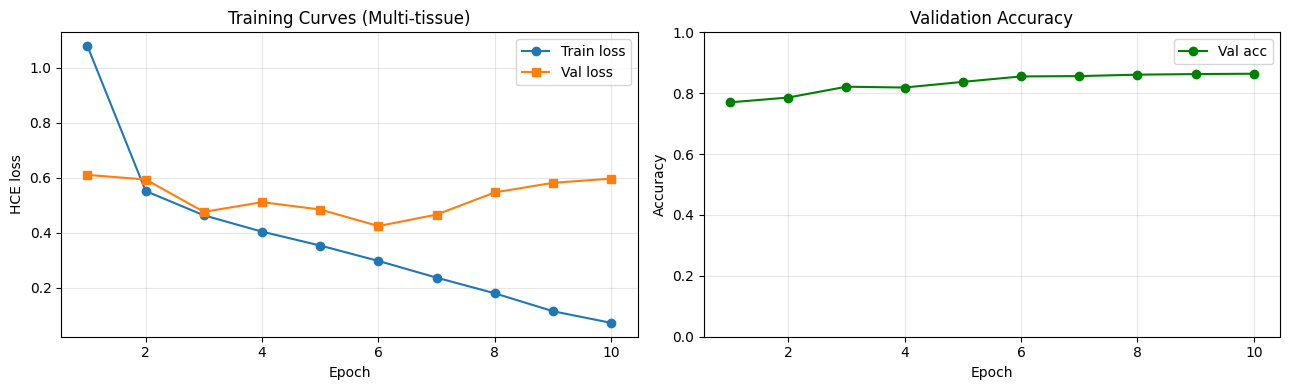

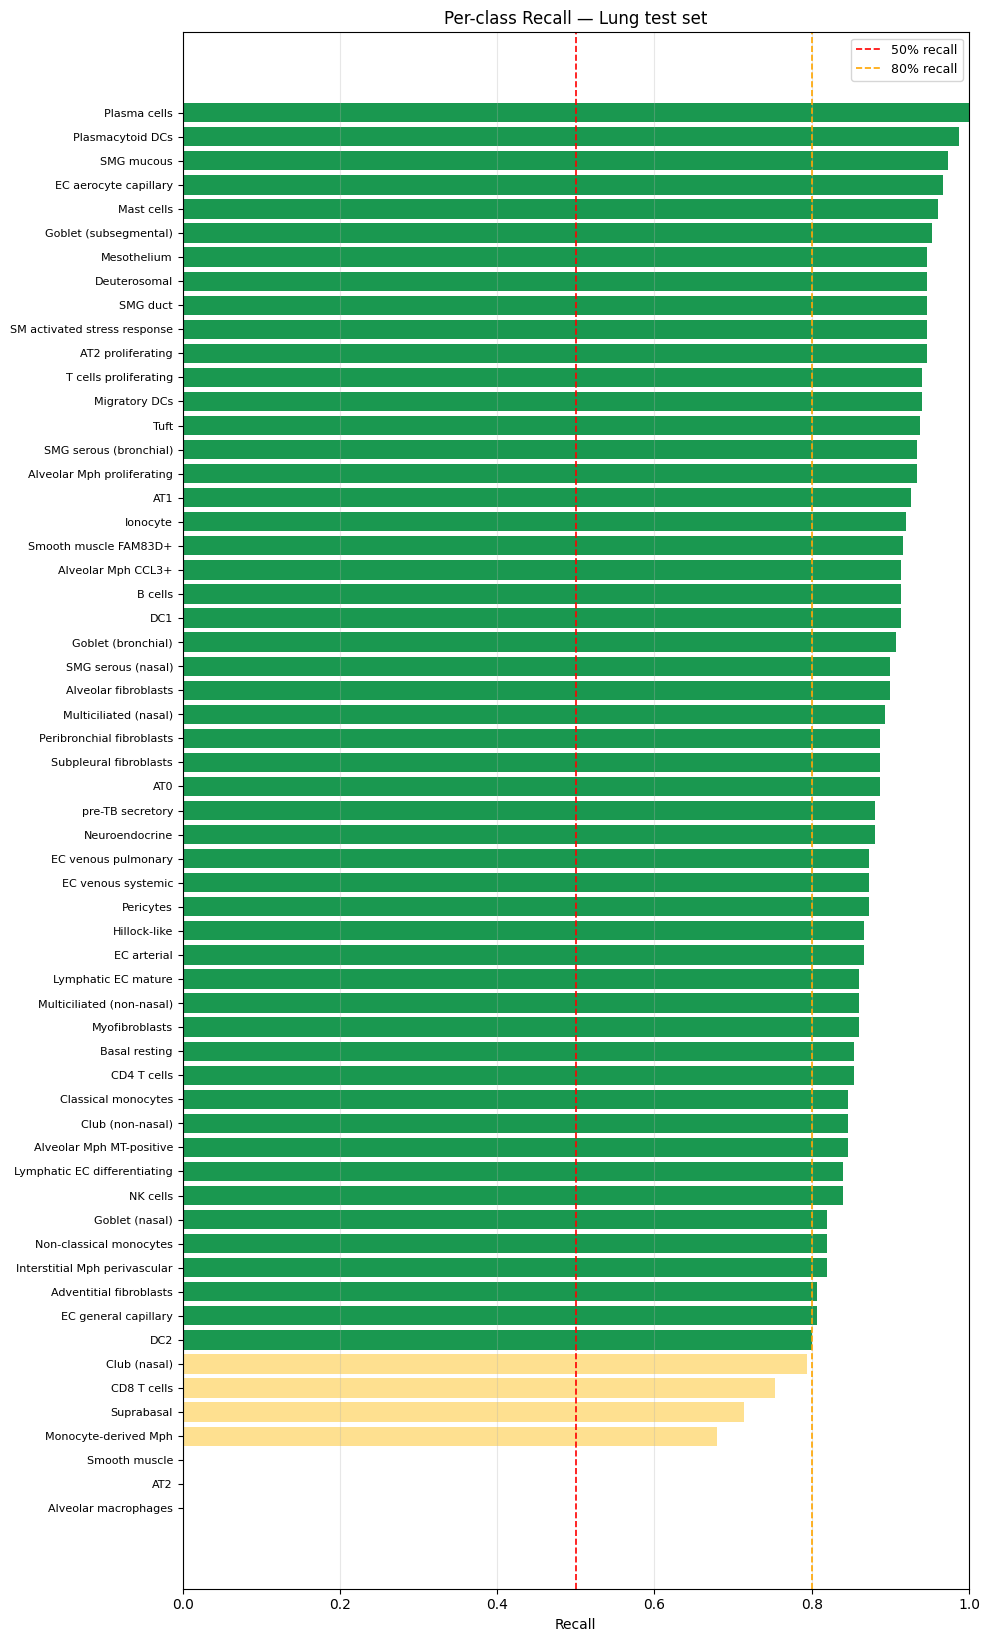

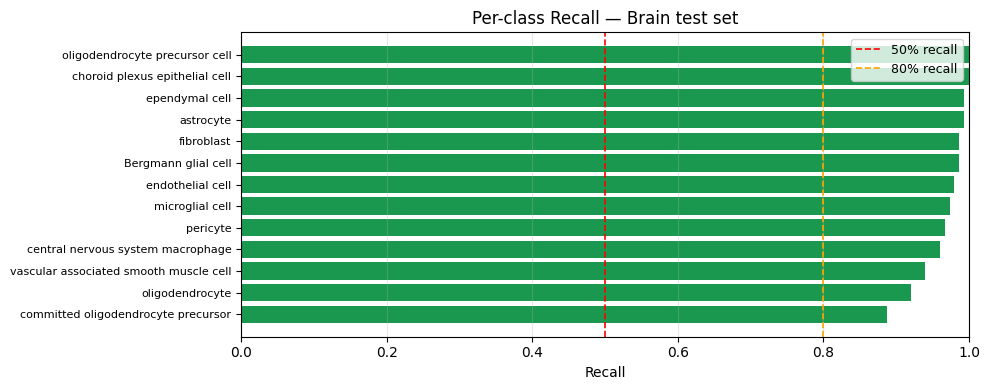

In [12]:
epochs_ax = np.arange(1, N_EPOCHS + 1)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs_ax, history['train_loss'], 'o-', label='Train loss')
axes[0].plot(epochs_ax, history['val_loss'],   's-', label='Val loss')
axes[0].set(xlabel='Epoch', ylabel='HCE loss', title='Training Curves (Multi-tissue)')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(epochs_ax, history['val_acc'], 'o-', color='green', label='Val acc')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation Accuracy', ylim=[0,1])
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class recall — lung
for pc_df, title, fname in [
    (lung_pc,  'Lung test set',   'lung_recall.png'),
    (brain_pc, 'Brain test set',  'brain_recall.png'),
]:
    pc_sorted = pc_df.sort_values('recall')
    fig, ax = plt.subplots(figsize=(10, max(4, len(pc_sorted) * 0.28)))
    colors  = ['#d73027' if r < 0.5 else '#fee090' if r < 0.8 else '#1a9850'
                for r in pc_sorted['recall']]
    ax.barh(pc_sorted['cell_type'], pc_sorted['recall'], color=colors)
    ax.axvline(0.5, color='red',    ls='--', lw=1.2, label='50% recall')
    ax.axvline(0.8, color='orange', ls='--', lw=1.2, label='80% recall')
    ax.set(xlabel='Recall', title=f'Per-class Recall — {title}', xlim=[0,1])
    ax.legend(fontsize=9); ax.tick_params(axis='y', labelsize=8); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()

## 13. Zero-shot Validation — All_cells

In [13]:
print('=' * 60)
print('  Zero-shot: All_cells')
print('=' * 60)
t0 = time.time()

adata_all    = sc.read_h5ad(ALL_CELLS_PATH)
all_gene_sym = np.array(adata_all.var_names.astype(str))
true_labels  = adata_all.obs[ALL_CELLS_ANN_COL].astype(str).values
unique_true  = sorted(set(true_labels))

print(f'  All_cells shape   : {adata_all.shape}')
print(f'  True label classes: {unique_true}')

# Gene overlap info
lung_sym_set  = set(lung_gene_symbols)
brain_sym_set = set(brain_gene_symbols)
all_sym_set   = set(all_gene_sym)
print(f'  Gene overlap (lung ∩ All_cells) : {len(lung_sym_set & all_sym_set):,} / {len(all_sym_set):,} genes')
print(f'  Gene overlap (brain ∩ All_cells): {len(brain_sym_set & all_sym_set):,} / {len(all_sym_set):,} genes')

# Convert All_cells to text (brain prefix — it is brain tissue)
def cell_to_text_dense(X_row, gene_symbols, top_k=100, tissue_prefix=''):
    row = X_row.toarray().flatten() if sp.issparse(X_row) else np.array(X_row).flatten()
    nz  = np.where(row > 0)[0]
    if len(nz) == 0: return ''
    vals = row[nz]
    if len(nz) > top_k:
        idx  = np.argpartition(vals, -top_k)[-top_k:]
        nz   = nz[idx[np.argsort(vals[idx])[::-1]]]
    else:
        nz   = nz[np.argsort(vals)[::-1]]
    genes = ' '.join(gene_symbols[i] for i in nz)
    return f'{tissue_prefix}{genes}'

print(f'  Converting {adata_all.n_obs:,} cells ...')
X_all = adata_all.X
all_cell_texts = [
    cell_to_text_dense(X_all[i], all_gene_sym, TOP_K_GENES, tissue_prefix='brain ')
    for i in tqdm(range(adata_all.n_obs), desc='  all_cells->text', leave=False)
]

class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.texts, self.tokenizer, self.max_length = texts, tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx] if self.texts[idx].strip() else '[PAD]',
            truncation=True, max_length=self.max_length,
            padding='max_length', return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0)}

inf_loader = DataLoader(
    InferenceDataset(all_cell_texts, tokenizer, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

ac_preds, ac_confs = [], []
model.eval()
with torch.no_grad():
    for batch in tqdm(inf_loader, desc='  Inference', leave=True):
        logits      = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        leaf_logits = logits[:, leaf_indices_t]
        probs       = torch.softmax(leaf_logits, dim=1)
        pred_pos    = leaf_logits.argmax(dim=1)
        ac_preds.extend(leaf_indices_t[pred_pos].cpu().numpy())
        ac_confs.extend(probs.max(dim=1).values.cpu().numpy())

ac_pred_names = [class_names[i] for i in ac_preds]
ac_confs      = np.array(ac_confs)

results_df = pd.DataFrame({
    'true_label': true_labels,
    'pred_label': ac_pred_names,
    'confidence': ac_confs,
})
results_df.to_csv(os.path.join(OUT_DIR, 'allcells_predictions.csv'), index=False)

print(f'  Elapsed            : {time.time()-t0:.1f}s')
print(f'  Mean confidence    : {ac_confs.mean():.4f}')
print(f'  Unique predictions : {len(set(ac_pred_names))}')
print('[OK] All_cells inference complete')

  Zero-shot: All_cells
  All_cells shape   : (2609, 27102)
  True label classes: ['AC-like', 'Astrocyte', 'CD4/CD8', 'DC', 'Endothelial', 'MES-like', 'NPC-like', 'Neuron', 'OPC', 'OPC-like', 'Oligodendrocyte', 'Pericyte', 'TAM-BDM', 'TAM-MG']
  Gene overlap (lung ∩ All_cells) : 19,130 / 27,102 genes
  Gene overlap (brain ∩ All_cells): 19,310 / 27,102 genes
  Converting 2,609 cells ...


  Inference: 100%|██████████| 164/164 [01:29<00:00,  1.84it/s]         

  Elapsed            : 110.3s
  Mean confidence    : 0.9419
  Unique predictions : 18
[OK] All_cells inference complete


## 14. All_cells Visualisations

In [14]:
breakdown = (
    results_df.groupby(['true_label', 'pred_label'])
    .size().reset_index(name='count')
)
breakdown['pct'] = breakdown.groupby('true_label')['count'].transform(lambda x: x / x.sum())
breakdown.to_csv(os.path.join(OUT_DIR, 'allcells_breakdown.csv'), index=False)

# Print: top predictions per true label
print('Top model predictions per All_cells label:\n')
for true_lbl in sorted(unique_true):
    sub     = breakdown[breakdown['true_label'] == true_lbl].sort_values('pct', ascending=False)
    n_total = sub['count'].sum()
    print(f'  {true_lbl} (n={n_total}):')
    for _, row in sub.head(3).iterrows():
        print(f'    → {row["pred_label"]:<45s}  {row["count"]:4d}  ({row["pct"]*100:.1f}%)')
    print()

Top model predictions per All_cells label:

  AC-like (n=200):
    → astrocyte                                        96  (48.0%)
    → committed oligodendrocyte precursor              58  (29.0%)
    → Bergmann glial cell                              15  (7.5%)

  Astrocyte (n=200):
    → astrocyte                                       189  (94.5%)
    → committed oligodendrocyte precursor               6  (3.0%)
    → Bergmann glial cell                               3  (1.5%)

  CD4/CD8 (n=200):
    → committed oligodendrocyte precursor              59  (29.5%)
    → central nervous system macrophage                56  (28.0%)
    → endothelial cell                                 48  (24.0%)

  DC (n=9):
    → central nervous system macrophage                 3  (33.3%)
    → microglial cell                                   3  (33.3%)
    → committed oligodendrocyte precursor               2  (22.2%)

  Endothelial (n=200):
    → endothelial cell                                175

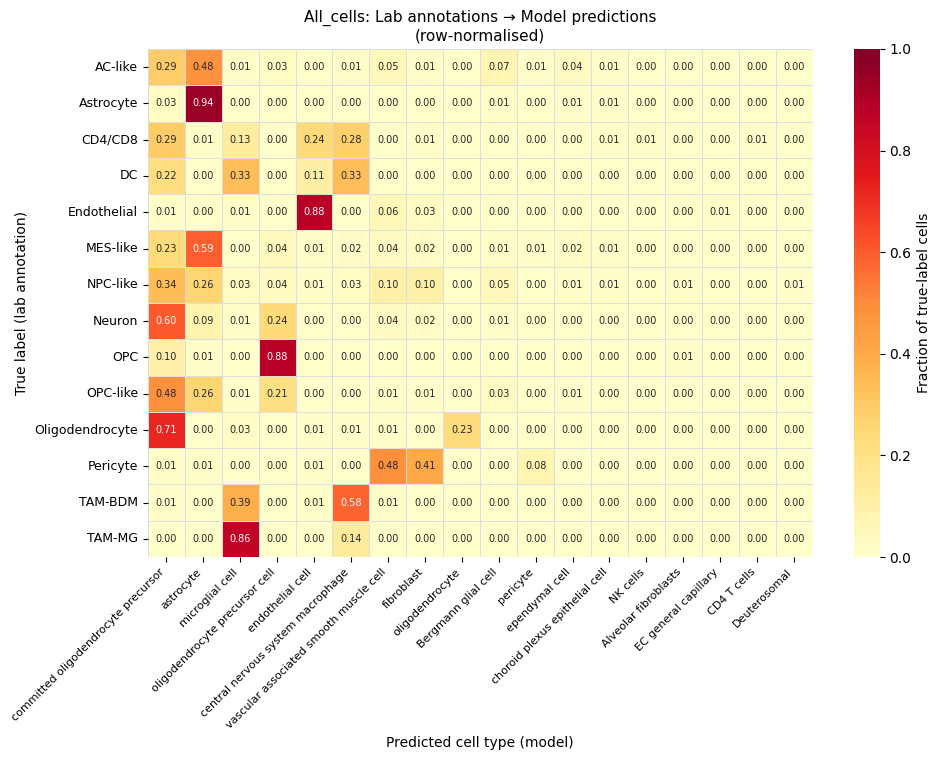

In [15]:
# Heatmap: true lab label (rows) vs predicted model label (cols)
pred_counts = results_df['pred_label'].value_counts()
active_preds = pred_counts[pred_counts > 0].index.tolist()

pivot = breakdown.pivot_table(
    index='true_label', columns='pred_label', values='pct', fill_value=0
).reindex(columns=[c for c in active_preds if c in breakdown['pred_label'].values], fill_value=0)

fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 0.45), max(6, len(pivot) * 0.55)))
sns.heatmap(
    pivot, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.4, linecolor='#dddddd',
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'label': 'Fraction of true-label cells'},
)
ax.set_xlabel('Predicted cell type (model)', fontsize=10)
ax.set_ylabel('True label (lab annotation)', fontsize=10)
ax.set_title('All_cells: Lab annotations → Model predictions\n(row-normalised)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'allcells_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

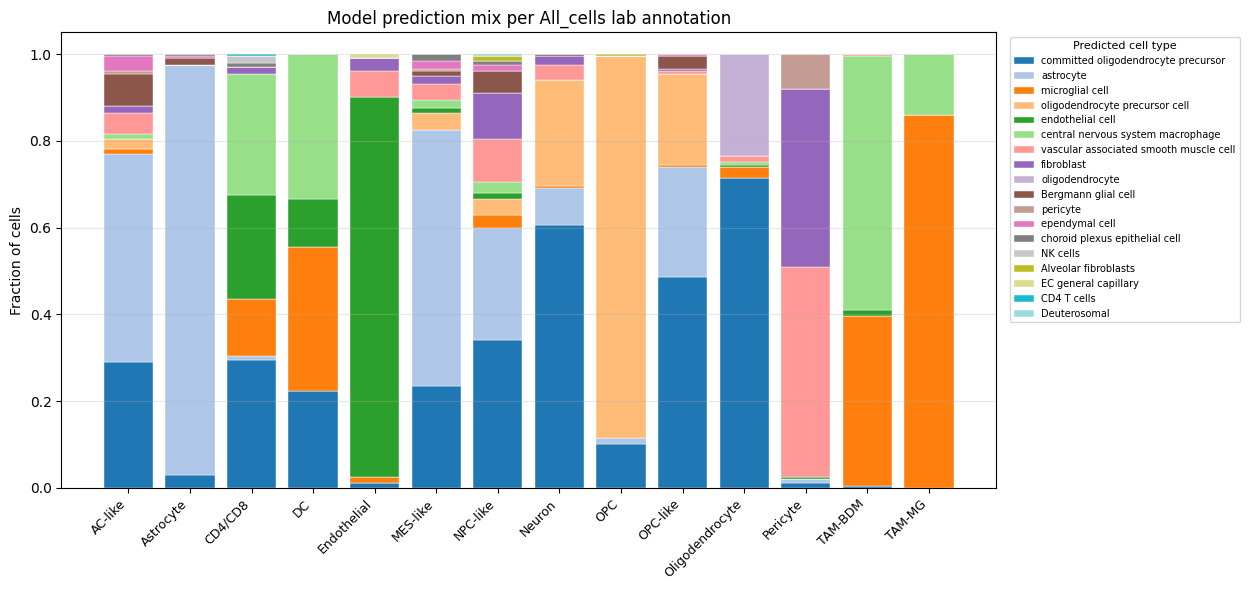

In [16]:
# Stacked bar: prediction mix per true label
palette   = plt.cm.get_cmap('tab20', len(active_preds))
color_map = {c: palette(i) for i, c in enumerate(active_preds)}

fig, ax = plt.subplots(figsize=(max(8, len(unique_true) * 0.9), 6))
bottoms = np.zeros(len(pivot))
x = np.arange(len(pivot))
for pred_cls in active_preds:
    if pred_cls not in pivot.columns: continue
    vals = pivot[pred_cls].values
    ax.bar(x, vals, bottom=bottoms, label=pred_cls, color=color_map[pred_cls],
           edgecolor='white', linewidth=0.3)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fraction of cells')
ax.set_title('Model prediction mix per All_cells lab annotation')
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7,
          title='Predicted cell type', title_fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'allcells_stacked_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

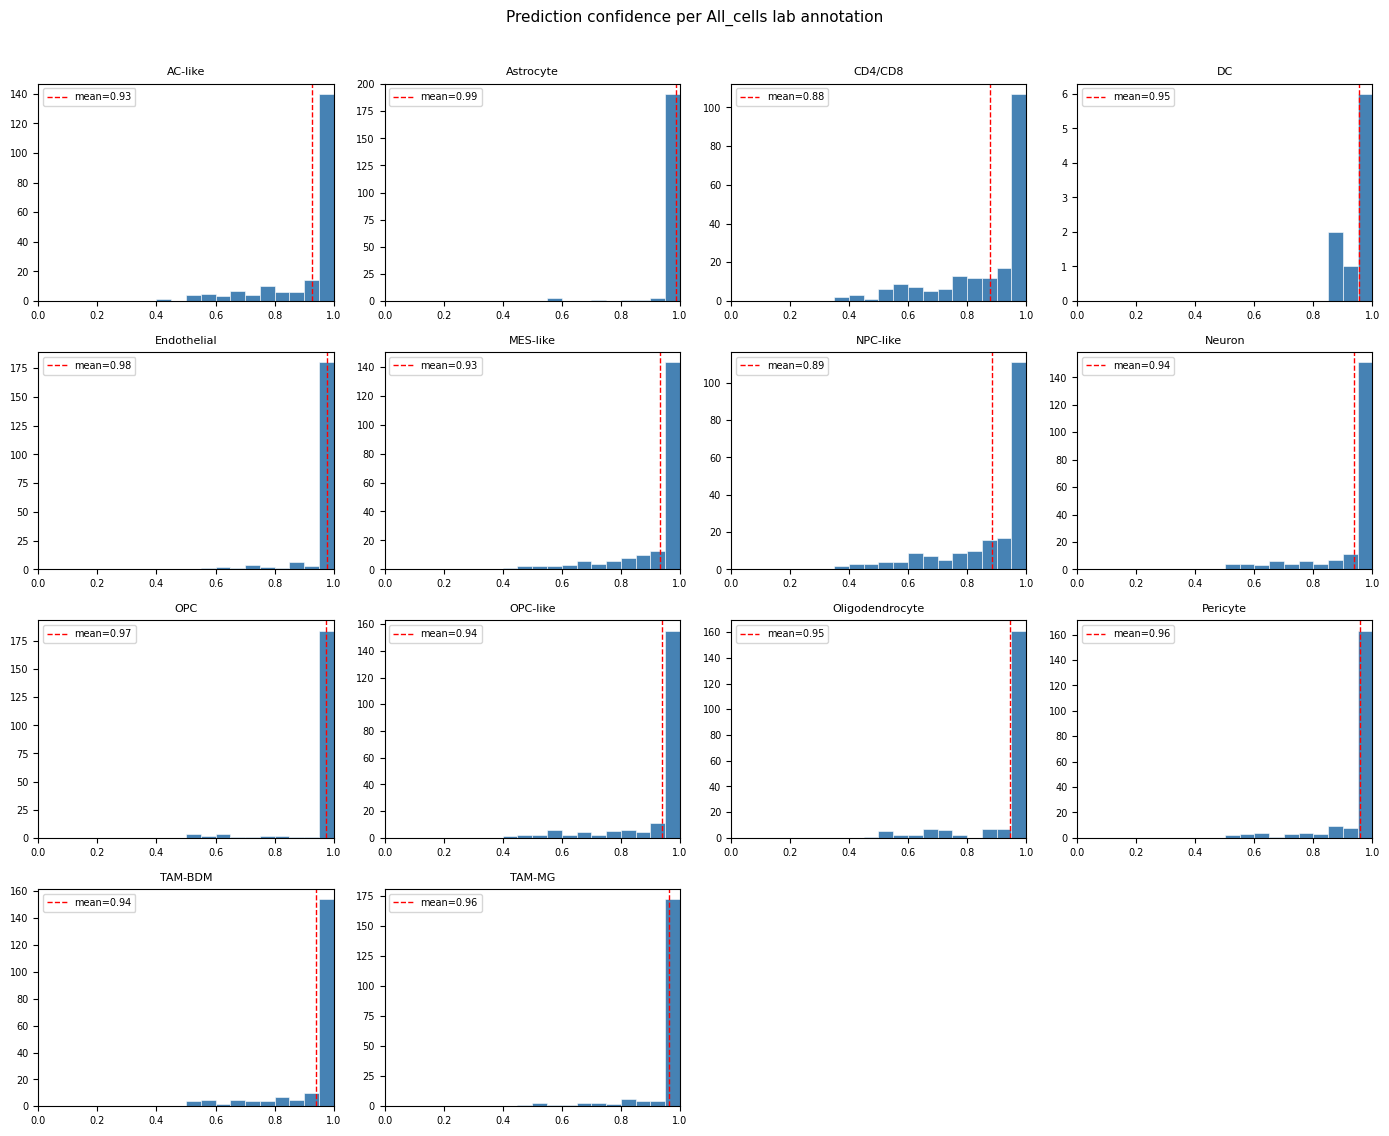

In [17]:
# Confidence distributions per true label
n_cols = 4
n_rows = int(np.ceil(len(unique_true) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 2.8))
axes = axes.flatten()
for i, true_lbl in enumerate(sorted(unique_true)):
    conf = results_df[results_df['true_label'] == true_lbl]['confidence'].values
    axes[i].hist(conf, bins=20, range=(0,1), color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].axvline(conf.mean(), color='red', ls='--', lw=1, label=f'mean={conf.mean():.2f}')
    axes[i].set_title(true_lbl, fontsize=8)
    axes[i].set_xlim(0, 1)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Prediction confidence per All_cells lab annotation', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'allcells_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Summary

In [ ]:
print('=' * 60)
print('  MULTI-TISSUE HCE TRAINING SUMMARY')
print('=' * 60)

lung_acc  = accuracy_score(test_trues[test_tissue == 0], test_preds[test_tissue == 0])
brain_acc = accuracy_score(test_trues[test_tissue == 1], test_preds[test_tissue == 1])

print(f"""
TRAINING DATA
=============
  Lung cells            : {len(lung_texts):,}
  Brain cells           : {len(brain_texts):,}
  Total cells           : {len(all_texts):,}
  Lung leaf classes     : {len(set(lung_labels))}
  Brain leaf classes    : {len(set(brain_labels))}
  Total leaf classes    : {len(leaf_classes)}
  Total vocab (w/ anc.) : {n_classes}

TEST SET PERFORMANCE
====================
  Lung  accuracy : {lung_acc:.4f}  ({lung_acc*100:.2f}%)
  Brain accuracy : {brain_acc:.4f}  ({brain_acc*100:.2f}%)

ALL_CELLS ZERO-SHOT
===================
  Cells              : {len(results_df):,}
  Unique predictions : {results_df['pred_label'].nunique()}
  Mean confidence    : {ac_confs.mean():.4f}
""")

print('  Dominant prediction per All_cells label:')
print(f'  {"Lab label":<35} {"Top prediction":<40} {"Frac":>6}')
print('  ' + '-' * 85)
for true_lbl in sorted(unique_true):
    sub = breakdown[breakdown['true_label'] == true_lbl].sort_values('pct', ascending=False)
    top = sub.iloc[0]
    print(f'  {true_lbl:<35} {top["pred_label"]:<40} {top["pct"]*100:5.1f}%')

print(f'\n[OK] Results saved to {OUT_DIR}/')

  MULTI-TISSUE HCE TRAINING SUMMARY

TRAINING DATA
  Lung cells            : 57,522
  Brain cells           : 13,000
  Total cells           : 70,522
  Lung leaf classes     : 59
  Brain leaf classes    : 13
  Total leaf classes    : 72
  Total vocab (w/ anc.) : 114

TEST SET PERFORMANCE
  Lung  accuracy : 0.8365  (83.65%)
  Brain accuracy : 0.9682  (96.82%)

ALL_CELLS ZERO-SHOT
  Cells              : 2,609
  Unique predictions : 18
  Mean confidence    : 0.9419

  Dominant prediction per All_cells label:
  Lab label                           Top prediction                             Frac
  -------------------------------------------------------------------------------------
  AC-like                             astrocyte                                 48.0%
  Astrocyte                           astrocyte                                 94.5%
  CD4/CD8                             committed oligodendrocyte precursor       29.5%
  DC                                  central nervous sys

: 